In [70]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [71]:
df = pd.read_csv("hart.csv")
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


EDA

In [72]:
df.shape

(1025, 14)

In [73]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [74]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [75]:
df.duplicated().sum()


np.int64(723)

In [76]:
df.isna().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [77]:
df.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')

<Axes: >

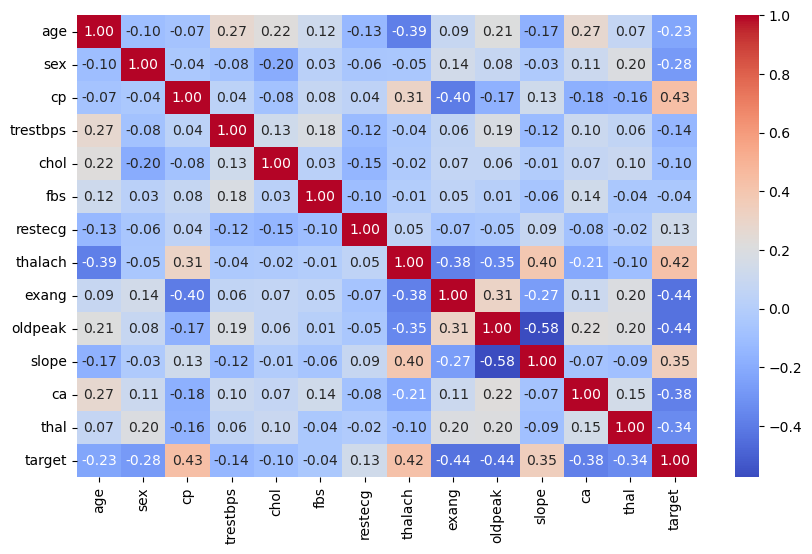

In [78]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')

Text(0.5, 1.0, 'Boxplots for Numeric Features')

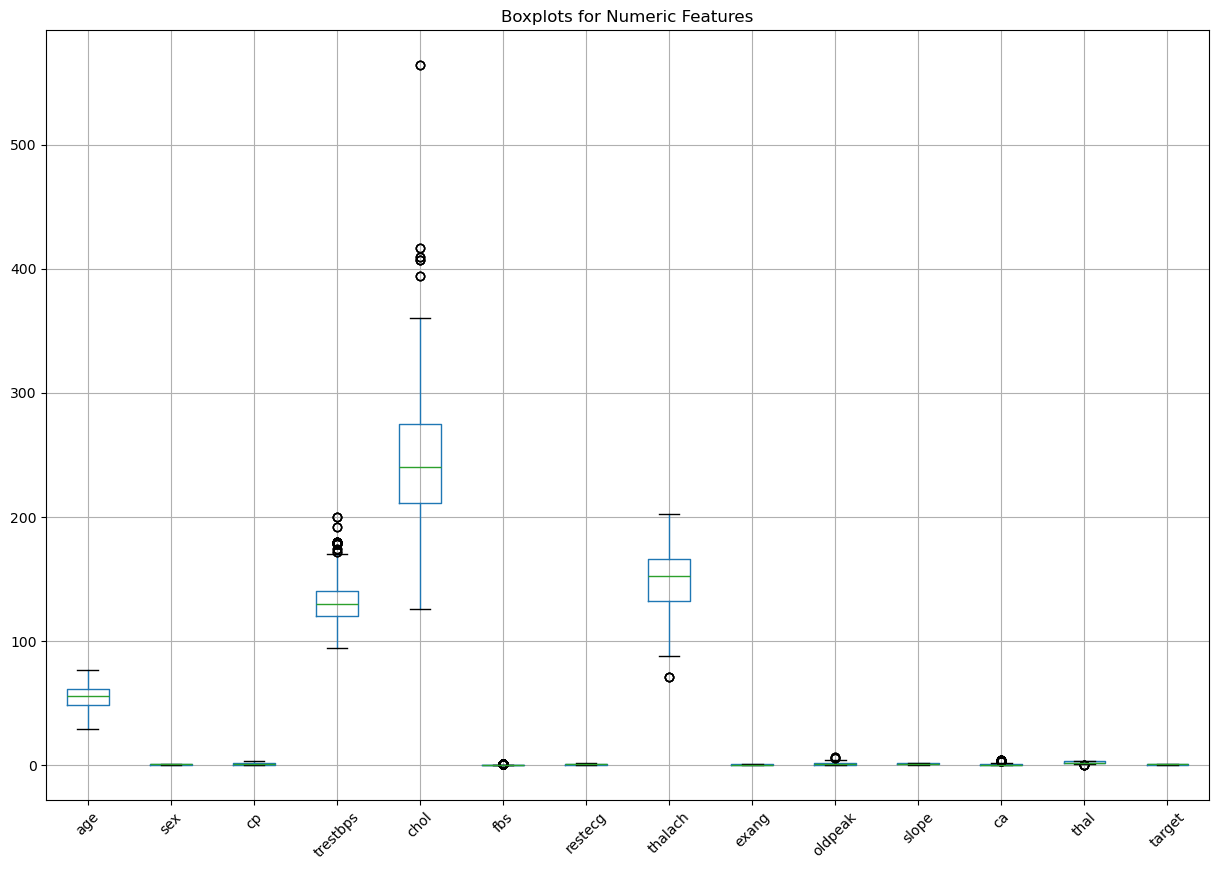

In [79]:
# outlier detection using boxplots
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

plt.figure(figsize=(15, 10))
df[num_cols].boxplot(rot=45)
plt.title('Boxplots for Numeric Features')

no problems - digestible outliers

<Axes: xlabel='target'>

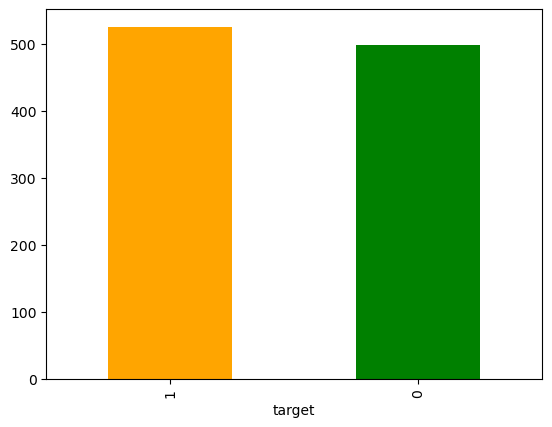

In [80]:
df['target'].value_counts().plot(kind='bar', color=['orange', 'green'])

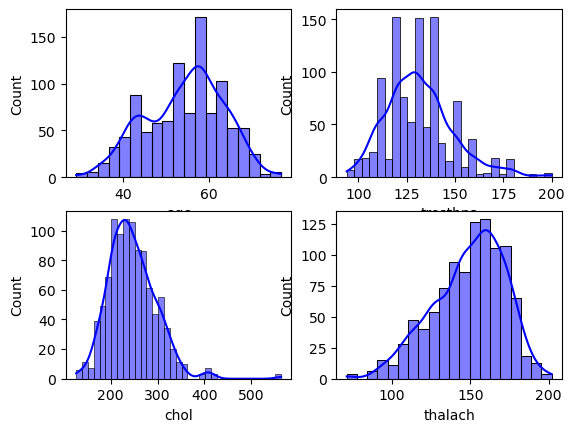

In [81]:
def plotting(var,num):
    plt.subplot(2,2,num)
    sns.histplot(df[var], kde=True, color='blue')
plotting('age', 1)
plotting('trestbps', 2)
plotting('chol', 3)
plotting('thalach', 4)

## Step 3: Linear Regression — Predicting Maximum Heart Rate

We start with a **Linear Regression** model to predict the maximum heart rate (`thalach`) using a single feature — `age`.

Steps:
1. Define `X = age` and `y = thalach`
2. Split the dataset into training and testing sets (80/20)
3. Train the model
4. Evaluate the R² score and visualize the regression line

The goal is to see how well age alone can explain a person’s maximum heart rate.


R^2 Score: 0.2138158688655435
Mean Squared Error: 440.5198930518084


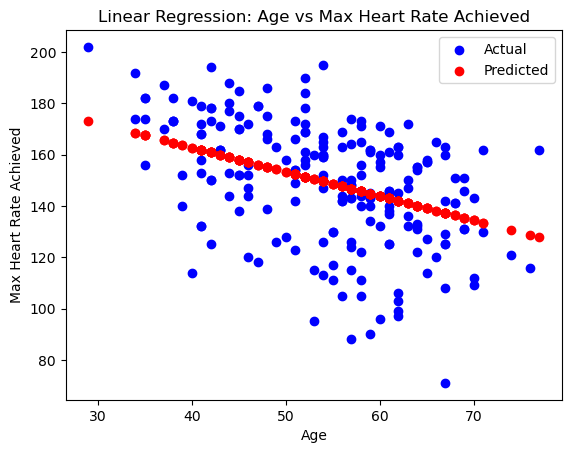

In [82]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression

X = df[['age']]
y = df['thalach']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,stratify=y)

model_lr = LinearRegression()
model_lr.fit(X_train, y_train)
y_pred = model_lr.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f'R^2 Score: {r2}')
print(f'Mean Squared Error: {mse}')

plt.scatter(X_test, y_test, color='blue', label='Actual')
plt.scatter(X_test, y_pred, color='red', label='Predicted')
plt.xlabel('Age')
plt.ylabel('Max Heart Rate Achieved')
plt.title('Linear Regression: Age vs Max Heart Rate Achieved')
plt.legend()
plt.show()


## Step 4: Logistic Regression — Predicting Heart Disease

Next, we build a **Logistic Regression** model to classify whether a patient has heart disease.

Features used:
- `age`
- `sex`
- `cp` (chest pain type)
- `trestbps` (resting blood pressure)
- `chol` (cholesterol level)

The target variable is `target` — 1 indicates the presence of heart disease, 0 indicates absence.


In [83]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

X = df[['age', 'sex', 'cp', 'trestbps', 'chol']]
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model_log_reg = LogisticRegression()
model_log_reg.fit(X_train, y_train)
y_pred = model_log_reg.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)
print(f'Accuracy: {accuracy}')
print('Confusion Matrix:')
print(conf_matrix)
print('Classification Report:')
print(class_report)

Accuracy: 0.7902439024390244
Confusion Matrix:
[[81 21]
 [22 81]]
Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.79      0.79       102
           1       0.79      0.79      0.79       103

    accuracy                           0.79       205
   macro avg       0.79      0.79      0.79       205
weighted avg       0.79      0.79      0.79       205



### Understanding the Metrics

- **F1-Score**: Balances *precision* (how many predicted positives are correct) and *recall* (how many actual positives are found).  
  Useful when false negatives and false positives both matter.

- **ROC-AUC**: Measures the area under the ROC curve.  
  AUC close to 1 means the model does an excellent job separating the two classes.  
  AUC = 0.5 indicates random guessing.


F1-Score: 0.7902
ROC-AUC Score: 0.8615


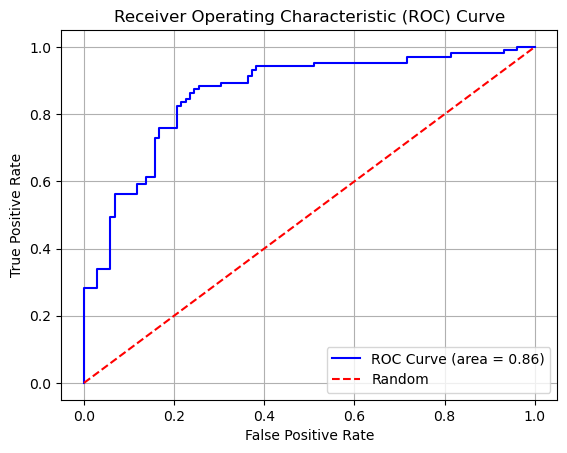

In [84]:
from sklearn.metrics import f1_score, roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# label predictions for F1
y_pred = model_log_reg.predict(X_test)
f1 = f1_score(y_test, y_pred)

# probability (or decision) scores for ROC-AUC
y_proba = model_log_reg.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, y_proba)

#ROC curve points from the same probabilities
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

print(f'F1-Score: {f1:.4f}')
print(f'ROC-AUC Score: {roc_auc:.4f}')

plt.figure()
plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


Bonus Challenge - Full Final Model

In [85]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler

X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# scale features
scaler = StandardScaler()
X_train_scale = scaler.fit_transform(X_train)
X_test_scale = scaler.transform(X_test)

model = LogisticRegression()
model.fit(X_train_scale, y_train)
y_pred = model.predict(X_test_scale)

accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)
print(f'Accuracy: {accuracy}')
print('Confusion Matrix:')
print(conf_matrix)
print('Classification Report:')
print(class_report)

Accuracy: 0.8097560975609757
Confusion Matrix:
[[70 30]
 [ 9 96]]
Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.70      0.78       100
           1       0.76      0.91      0.83       105

    accuracy                           0.81       205
   macro avg       0.82      0.81      0.81       205
weighted avg       0.82      0.81      0.81       205



F1-Score: 0.8312
ROC-AUC Score: 0.9298


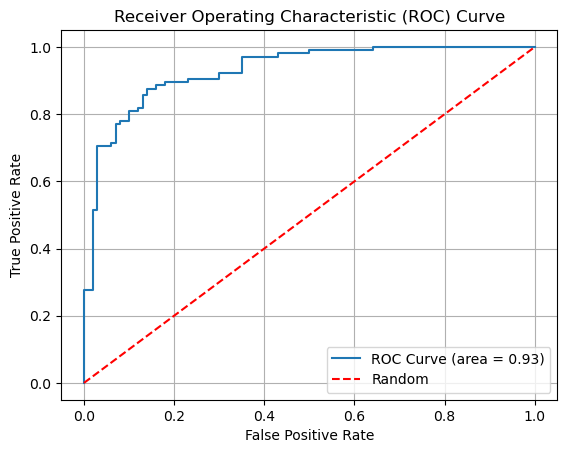

In [86]:
from sklearn.metrics import f1_score, roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# predictions (labels) for F1
y_pred = model.predict(X_test_scale)
f1 = f1_score(y_test, y_pred)

# probabilities for ROC-AUC and ROC curve
y_proba = model.predict_proba(X_test_scale)[:, 1]
roc_auc = roc_auc_score(y_test, y_proba)
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

print(f'F1-Score: {f1:.4f}')
print(f'ROC-AUC Score: {roc_auc:.4f}')

plt.figure()
plt.plot(fpr, tpr, label=f'ROC Curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='red', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

## Step 6: Conclusion

### Key Insights
- **Age vs. Thalach:** As expected, older people generally have lower maximum heart rates.
- **Selected-Feature Logistic Model:** Achieved decent classification results.
- **Full-Feature Model with Scaling:** Substantially improved performance — AUC > 0.9, showing strong predictive power.

### Takeaways
- Scaling and feature expansion can greatly enhance model performance.
- Logistic regression is effective and interpretable for medical classification problems.
- Future improvements could include:
  - Feature selection using statistical methods
  - Hyperparameter tuning via GridSearchCV
  - Trying tree-based models for nonlinear relationships

Overall, the experiment demonstrates how simple linear models can still produce valuable predictive insights when properly scaled and evaluated.
